<a href="https://colab.research.google.com/github/dbstj118/2026_2-1_BDA/blob/main/07w_pydataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#패키지 pydataset 활용

###패키지 pydatyaset 설치

In [54]:
!pip install pydataset

In [55]:
!pip show seaborn

Name: seaborn
Version: 0.13.2
Summary: Statistical data visualization
Home-page: 
Author: 
Author-email: Michael Waskom <mwaskom@gmail.com>
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: matplotlib, numpy, pandas
Required-by: missingno, segregation, splot


###전체 자료 정보

In [56]:
from pydataset import data

all_data = data()
all_data

,dataset_id,title
0,AirPassengers,Monthly Airline Passenger Numbers 1949-1960
1,BJsales,Sales Data with Leading Indicator
2,BOD,Biochemical Oxygen Demand
3,Formaldehyde,Determination of Formaldehyde
4,HairEyeColor,Hair and Eye Color of Statistics Students
...,...,...
752,VerbAgg,Verbal Aggression item responses
753,cake,Breakage Angle of Chocolate Cakes
754,cbpp,Contagious bovine pleuropneumonia
755,grouseticks,Data on red grouse ticks from Elston et al. 2001


In [57]:
type(all_data)

pandas.core.frame.DataFrame

In [58]:
all_data.describe()

,dataset_id,title
count,757,757
unique,727,702
top,Hedonic,Seven data sets showing a bifactor solution.
freq,2,8


###주요 자료 titannic 가져오기

In [59]:
data('titanic',show_doc=True)

titanic

PyDataset Documentation (adopted from R Documentation. The displayed examples are in R)

## titanic

### Description

The data is an observation-based version of the 1912 Titanic passenger
survival log,

### Usage

    data(titanic)

### Format

A data frame with 1316 observations on the following 4 variables.

`class`

a factor with levels `1st class` `2nd class` `3rd class` `crew`

`age`

a factor with levels `child` `adults`

`sex`

a factor with levels `women` `man`

`survived`

a factor with levels `no` `yes`

### Details

titanic is saved as a data frame. Used to assess risk ratios

### Source

Found in many other texts

### References

Hilbe, Joseph M (2014), Modeling Count Data, Cambridge University Press Hilbe,
Joseph M (2007, 2011), Negative Binomial Regression, Cambridge University
Press Hilbe, Joseph M (2009), Logistic Regression Models, Chapman & Hall/CRC

### Examples

    data(titanic)
    titanic$survival <- titanic$survived == "yes"
    glmlr <- glm(survival ~

In [60]:
df = data('titanic')
df

,class,age,sex,survived
1,1st class,adults,man,yes
2,1st class,adults,man,yes
3,1st class,adults,man,yes
4,1st class,adults,man,yes
5,1st class,adults,man,yes
...,...,...,...,...
1312,3rd class,child,women,no
1313,3rd class,child,women,no
1314,3rd class,child,women,no
1315,3rd class,child,women,no


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1316 entries, 1 to 1316
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   class     1316 non-null   object
 1   age       1316 non-null   object
 2   sex       1316 non-null   object
 3   survived  1316 non-null   object
dtypes: object(4)
memory usage: 51.4+ KB


In [62]:
df.describe()

,class,age,sex,survived
count,1316,1316,1316,1316
unique,3,2,2,2
top,3rd class,adults,man,no
freq,706,1207,869,817


###자동차 연비 자료 mpg 가져오기

In [63]:
all_data[all_data.title.str.contains('car')]

,dataset_id,title
382,mpg,Fuel economy data from 1999 and 2008 for 38 popular models of car


In [64]:
dfm = data('mpg')
dfm.head()

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
1,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
2,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
3,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
4,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
5,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact


###한글처리+선명

In [65]:
!pip install koreanize-matplotlib
import koreanize_matplotlib
%config InlineBackend.figure_format = 'retina'

###열 'manufacturer'인 자동차 생산 회사의 빈도수

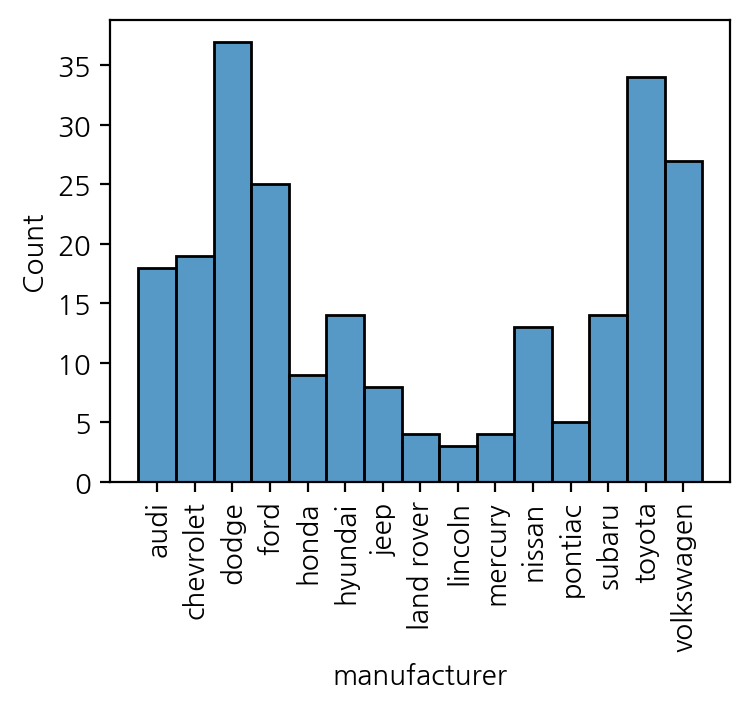

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(4,3))
sns.histplot(dfm['manufacturer'])
plt.xticks(rotation=90)
plt.show()

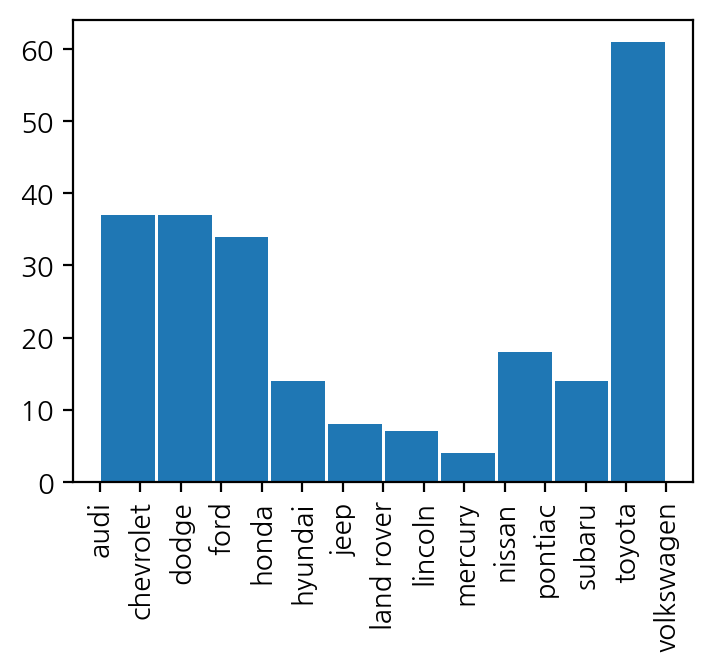

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4,3))
plt.hist(dfm.manufacturer, rwidth=.95)
plt.xticks(rotation=90)
plt.show()

#외부 파일 활용

###타이타닉

In [68]:
import pandas as pd

titanic = pd.read_excel('titanic.xlsx',index_col=0)
titanic

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN


###csv파일로 쓰기와 읽기

In [69]:
titanic.to_csv("my_titanic.csv")

In [70]:
tt = pd.read_csv("my_titanic.csv",index_col=0)
tt

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN


###인터넷 자료의 파일 읽기와 쓰기

In [71]:
traffic = pd.read_csv('2022년도시도별교통사고.csv',encoding='cp949')
traffic

,2022년도 시도별 교통사고,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,시도,사고건수(건),사망자수(명),부상자수(명)
1,전국,"196,836","2,735","281,803"
2,서울,"33,698",221,"45,329"
3,부산,"10,882",113,"14,829"
4,경기,"52,968",547,"77,377"
5,강원,"6,425",139,"10,160"
6,충북,"7,644",149,"11,354"
7,충남,"8,164",230,"11,964"
8,전북,"5,681",194,"8,091"
9,전남,"8,335",201,"12,611"


In [72]:
traffic = pd.read_csv('2022년도시도별교통사고.csv',encoding='cp949',skiprows=1,index_col=0)
traffic.head()

,사고건수(건),사망자수(명),부상자수(명)
시도,,,
전국,"196,836","2,735","281,803"
서울,"33,698",221,"45,329"
부산,"10,882",113,"14,829"
경기,"52,968",547,"77,377"
강원,"6,425",139,"10,160"


In [73]:
traffic.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18 entries, 전국 to 세종
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   사고건수(건)  18 non-null     object
 1   사망자수(명)  18 non-null     object
 2   부상자수(명)  18 non-null     object
dtypes: object(3)
memory usage: 576.0+ bytes


In [74]:
traffic = pd.read_csv('2022년도시도별교통사고.csv',encoding='cp949',skiprows=1,index_col=0,thousands=',')
traffic.head()

,사고건수(건),사망자수(명),부상자수(명)
시도,,,
전국,196836,2735,281803
서울,33698,221,45329
부산,10882,113,14829
경기,52968,547,77377
강원,6425,139,10160


In [75]:
traffic.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18 entries, 전국 to 세종
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   사고건수(건)  18 non-null     int64
 1   사망자수(명)  18 non-null     int64
 2   부상자수(명)  18 non-null     int64
dtypes: int64(3)
memory usage: 576.0+ bytes


In [76]:
plt.rcParams['figure.figsize'] = [4,2]

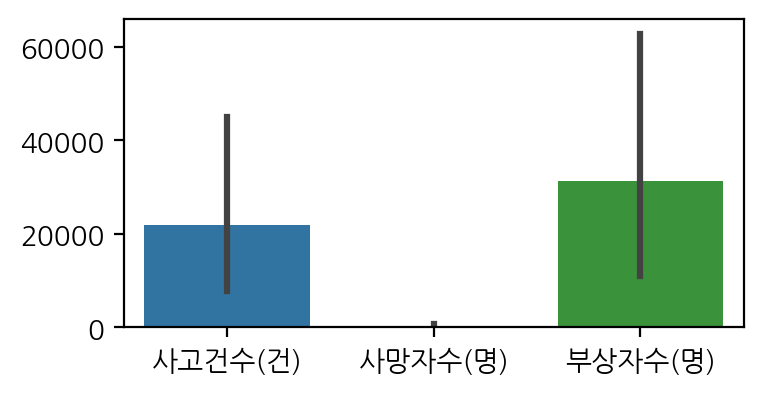

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(traffic)
plt.show()

In [78]:
(traffic['사망자수(명)'])

,사망자수(명)
시도,
전국,2735
서울,221
부산,113
경기,547
강원,139
충북,149
충남,230
전북,194
전남,201


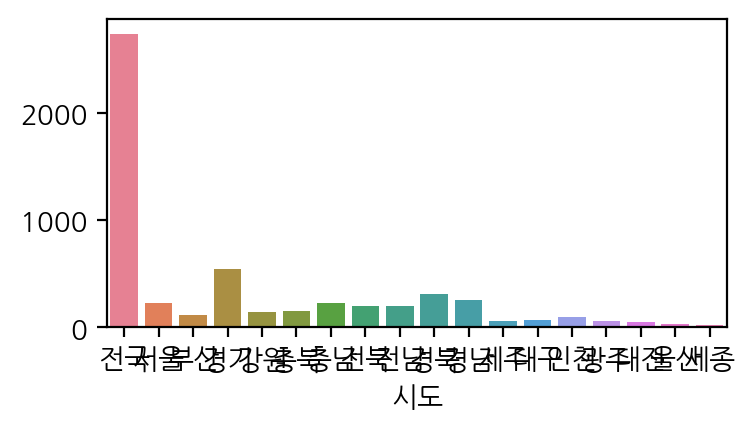

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(traffic[['사망자수(명)']].T)
plt.show()

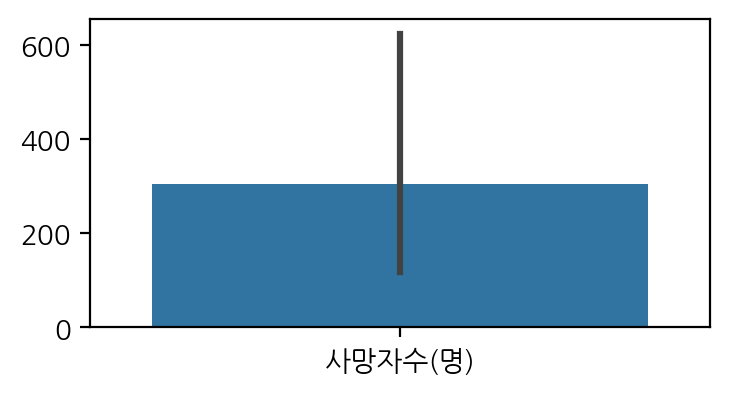

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(traffic[['사망자수(명)']])
plt.show()

In [81]:
traffic.columns[2]

'부상자수(명)'

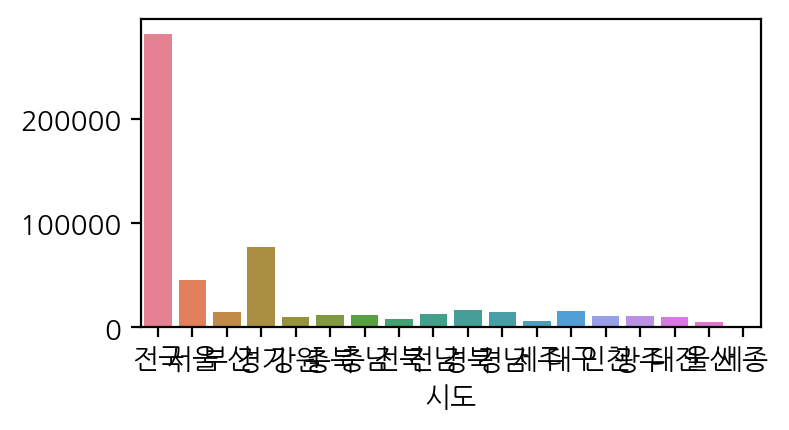

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(traffic[[traffic.columns[2]]].T)
plt.show()

In [83]:
dfm

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
1,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
2,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
3,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
4,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
5,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact
...,...,...,...,...,...,...,...,...,...,...,...
230,volkswagen,passat,2.0,2008,4,auto(s6),f,19,28,p,midsize
231,volkswagen,passat,2.0,2008,4,manual(m6),f,21,29,p,midsize
232,volkswagen,passat,2.8,1999,6,auto(l5),f,16,26,p,midsize
233,volkswagen,passat,2.8,1999,6,manual(m5),f,18,26,p,midsize


In [84]:
dfm.columns

Index(['manufacturer', 'model', 'displ', 'year', 'cyl', 'trans', 'drv', 'cty',
       'hwy', 'fl', 'class'],
      dtype='object')

In [85]:
dfm.fl.value_counts()

,count
fl,
r,168
p,52
e,8
d,5
c,1


In [86]:
dfm['fl'].value_counts()

,count
fl,
r,168
p,52
e,8
d,5
c,1


In [87]:
dfm['fl'].value_counts(ascending=True)

,count
fl,
c,1
d,5
e,8
p,52
r,168
